<a href="https://colab.research.google.com/github/Isacc-Mex/9aEVND-PRACTICASdb-230372/blob/Practica02/Practica02/Practica02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análitica de Datos para Negocios Digitales

### Práctica 02: Introduccion al uso de Python en el Análisis de Datos

Elaborado por : Cristian Isacc Moreno Jimenez
Grado/Grupo 9° "A" EVND
Matrícula: 230372

**1. Importamos la librerias de python para manipular y analizar datos**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mat
import seaborn as sea

**2. Creamos un DataFrame del origen d elos datos en este caso un archivo delimitado por comas**

este comando perimte cargar en memoria cache(temporal), los datos que se van a analizar estan utilizando las librerias de panda que nos permite la manipulacion de datos

In [6]:
df=pd.read_csv('UberDataset.csv')


**3. imprimimos en pantalla los datos para verificar la carga completas**

**IMPORTANTE** la impresion de los datos del DATAFRAME no da contexto importante como el numnro de filas, el numero de columnas y en el caso de los datos **cuantitativos** una suma de total de las columnas, en caso de los casos **cualitativos** nos colocara en texto NaN (Not As Number) por defecto no s epuede sumar  

In [7]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**4. leer los datos de una columna especifica**

el uso de **[Columna]** nos permite poder acceder a los datos de la columna del DataFrame, mostrando los 5 primeros y 5 ultimos el total de registro y el tipo de datos cabe mencionar que este comando

In [8]:
df['PURPOSE']

,PURPOSE
0,Meal/Entertain
1,NaN
2,Errand/Supplies
3,Meeting
4,Customer Visit
...,...
1151,Temporary Site
1152,Meeting
1153,Temporary Site
1154,Temporary Site


**5. Manipulamos los dtaos cargados para obtener el total de cada valor registrado en la columna**

El metodo value.counts()es una funcion preprogramada de python que nos permite agrupar los registro por sus valores y obtener el total de cada valor detectado

In [9]:
df['PURPOSE'].value_counts()

,count
PURPOSE,
Meeting,187
Meal/Entertain,160
Errand/Supplies,128
Customer Visit,101
Temporary Site,50
Between Offices,18
Moving,4
Airport/Travel,3
Commute,1


**6. Aplicamos las mismas funcion con otra columna**

en este caso vemos que tipo de viajes hizo el conductor, resultado **Business** (Negocios) o **'Personal'** (Autos personales)

In [10]:
df['CATEGORY'].value_counts()

,count
CATEGORY,
Business,1078
Personal,77


**Limpiamos el resgistro de los viajes que no tinen un localizacion de inicio**

In [11]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**7. LIMPIAMOS LOS REGISTROS DE LOS VIAJES QUE NO SON LOCALIZABLES**

para este analisis es importante limpiar los datos de la muestra que nos sirve para para nuestro analisis, empezamos por eliminar los registros (filas), de aquellos viajes que no registraron un destino localizable, para ello y utilizamos el comando logico de no igualdad (!=) para filtrar el dataframe, esto nos arroja a un resultado de boloeano "true" para los que tiene un destino localizable "false" para los que no.

In [12]:
df['STOP']!='Unknown Location'

,STOP
0,True
1,True
2,True
3,True
4,True
...,...
1150,True
1151,False
1153,True
1154,True


**8. Eliminamos del DataFrame los registros  que contengan false**

In [13]:
df[df['STOP']!='Unknown Location']

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**9. sobreescribimos el DataFrame (df)**

para eliminar de nuestro analisis es decir que que el docimento de origen de los datos(csv) sigue sin cambios, asignamos el resu

In [14]:
df=df[df['STOP']!='Unknown Location']

**10. Volvemos a imprimir el dataframe**

En este resultado en este resultado podemos observar que el numero datframe cuanta con solo 1007 filas a diferencias del original que tenia 1156 es  decir se eliminaron 149 registros que no tenian un destino localizable.

In [15]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


**11. Repetimos el proceso de limpieza ahora para los viajes que no tienen un origen localizable (SMART)**

en este caso hacemos toda la limpieza en una sola operacion, para el analisis de datos reduciendo de **1007** a **945** registros, incluyendo que hay **62** viajes que tuvieron un destino (STOP) pero no unorigen (START)

In [16]:
df=df[df['START']!='Unknown Location']
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Kar?chi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [17]:
def value(val):
    val=str(val)
    return val.replace('?','a')
df['START']=df['START'].apply(value)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Kar?chi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Kar?chi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


12. **Conceptos de Repaso**

    *12.1 Funciones en Métodos de Python*
Una función o método es un bloque de código reutilizable que realiza una tarea especifica. Sirve para evitar repetir instrucciones y organizar mejor nlos programas.
En el lenguaje de Python las funciones son declaradas con la palabra reservada **def**, y para ejecutarlas basta con escribir el nombre que se le asigno a la misma.

In [18]:
def saludar():
    print("Hola mundo")

Llamando

In [19]:
saludar()

Hola mundo


12.2 Funciones que reciben un parametro o datos de entrda en algunas ocasiones es necesario enviar datos para la ejecución del método, para ello debemos declararlo en la definición de la función entre()

Definición

In [20]:
def saludar_nombre(nombre):
    return f"Hola, {nombre}, Bienvenid@ a Python para el Análisis de Datos"

Llamando

In [21]:
saludar_nombre("Isacc")

'Hola, Isacc, Bienvenid@ a Python para el Análisis de Datos'

In [22]:
saludar_nombre("Andrea Peña")

'Hola, Andrea Peña, Bienvenid@ a Python para el Análisis de Datos'

12.3 Funciones que mandan *llamar otras funciones y que regresan el resultado de procesamiento*, en este caso utilizaremos una función predefinida en Python denominada *replace* que nos permite sustituir letras en una cadena de texto.

Definición:

In [23]:
def sustituir_vocales(texto):
    texto = texto.replace("A","4")
    texto = texto.replace("a","4")

    texto = texto.replace("E","3")
    texto = texto.replace("e","3")

    texto = texto.replace("I","1")
    texto = texto.replace("i","1")

    texto = texto.replace("O","0")
    texto = texto.replace("o","0")

    texto = texto.replace("U","∪")
    texto = texto.replace("u","∪")
    return texto

Llamando

In [24]:
print (sustituir_vocales(saludar_nombre("Isacc")))

H0l4, 1s4cc, B13nv3n1d@ 4 Pyth0n p4r4 3l 4nál1s1s d3 D4t0s


13. **Limpieza de letras ilegibles**
Ejecutamos el proceso de sustitución de las letras ilegible (para este caso de estudio solo hay letras a con tilde que se cargaron con un ?, y se limpian con una "a" para mejor comprensión del análisis.

In [25]:
df ['START'] = df['START'].astype(str).str.replace('?', 'a')
df ['STOP'] = df['STOP'].astype(str).str.replace('?', 'a')
df


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


14. **Rellenar datos vacios por un valor generico asignado**
Durante el proceso de la limpieza y transformación de los datos, existe la posibilidad de corregir datos que no se encuentran registrados, para este caso usaremos una función de **PANDAS** LLAMADO *fillna*,(sirve para rellenar los datos no disponibles (not avalaible) en este caso serán sustituidos por la palabra *Others*, en el DataFrame original por eso se activa **inplace=True**

In [26]:
df ['PURPOSE'].fillna('Others',inplace=True)
df

/tmp/ipykernel_1250/2013808692.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df ['PURPOSE'].fillna('Others',inplace=True)


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016 23:06,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


15. **Medidas de Téndencia Central**

Una vez terminada la fase de limpieza de datos, comenzamos con la Estadistica de Básica, en este caso consultaremos las medidas de tendencia central siendo:Total, Media, Cuartiles y Desviación Estánadar, Máximo y Mínimo.

Utilizando en método **describe** de nuestro dataframe, se buscaran todos los datos cuantitativos (Númericos) de la muestra y realizará el cálculo de estos valores, para este caso en especifico solo tenemos la columna **MILES**, la cual hace referencia al total de millas Terrestres (1.609 km) recorridas por el conductor en un servicio de viaje a travéz de UBER.

In [27]:
df.describe()

,MILES
count,945.000000
mean,22.809841
std,397.276813
min,0.500000
25%,2.600000
50%,5.300000
75%,9.900000
max,12204.700000


Para el caso de Mediana y Moda, estas debe ser calculadas por separado a través de las funciones .mode y .median

In [28]:
print(df['MILES'].mode())

0    9.9
Name: MILES, dtype: float64


In [29]:
print(df['MILES'].median())

5.3


En **conclusión** este dataframe nos permite analizar una pequeña muestra de **945** Viajes Realizados a través de la plicación de Uber, determinando que la distancia mínima registrada es de **.5** millas y las máxima de **12204.7** millas, con un promedio **22.8** millas, siendo la distancia más repetida de **9.9** millas y la mediana de **5.3** millas.

16. **Limpieza de Datos: Segmentar la fecha del viaje, ignotando la HH:**

In [30]:
def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-', '/')
df['START_DATE']=df['START_DATE'].apply(val)

def val(value):
    value=str(value)
    value=value.split()
    return value[0].replace('-', '/')
df['START_DATE']=df['END_DATE'].apply(val)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


17. **Eliminamos la ultima fila de totales**

    La ultima fila de totales no es necesaria para la graficacion dado que podria generar error en la representacion de datos, por ello los eliminamos del DataFrame usando el comando drop y el numero de la posicion de la fila a eliminar encerrada entre corchetes []

In [31]:
df.drop([1155], inplace=True)
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01/06/2016,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting
1153,12/31/2016,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


18.**Filtrado de valores atípicos mediante percentiles**

Se calcularon los percentiles 5 y 95 de la columna `MILES` para establecer un rango de valores representativos dentro del conjunto de datos. Posteriormente, se aplicó un filtro para conservar únicamente los registros cuya distancia recorrida se encuentra entre ambos límites, eliminando posibles valores atípicos (outliers) y facilitando un análisis más consistente de la información.

In [32]:
a=df['MILES'].quantile(0.95)
b=df['MILES'].quantile(0.05)
df3=df[df['MILES']>b]
df3=df[df['MILES']<a]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
5,01/06/2016,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting


19. **Calculo de la Desviacion Estandar**

Para entender que tan variables o dispersas son las distancias de los viajes.

In [33]:
df3['STD']=df.MILES.std()
df3

/tmp/ipykernel_1250/672307851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['STD']=df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805
5,01/06/2016,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805
...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting,21.472805
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit,21.472805
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting,21.472805


20. **Estimar el Valor de Z-Score o Puntuación Z**

Con la finalidad de estimar la dispercion de los datos, es decir que tan variados o diferentes son, utilizamos esta formula estadística para poder continuar con el análisis EDA(Exploratory Data Analisys)

In [34]:
df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()
df3

/tmp/ipykernel_1250/2738585948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['Z']=(df.MILES-df.MILES.mean())/df.MILES.std()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


21. **Filtramos aquello que no estén en el rango -1 y 1**

In [35]:
df['MILES'].describe()

,MILES
count,944.000000
mean,9.905297
std,21.472805
min,0.500000
25%,2.600000
50%,5.300000
75%,9.900000
max,310.300000


In [36]:
df3['MILES'].describe()

,MILES
count,896.000000
mean,6.344196
std,4.849186
min,0.500000
25%,2.500000
50%,4.900000
75%,9.025000
max,25.600000


In [37]:
df3=df3[(df3.Z>-1) & (df3.Z<1)]
df3

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,STD,Z
0,01/01/2016,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.472805,-0.223785
1,01/02/2016,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Others,21.472805,-0.228442
2,01/02/2016,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,21.472805,-0.237756
3,01/05/2016,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,21.472805,-0.242413
5,01/06/2016,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain,21.472805,-0.261042
...,...,...,...,...,...,...,...,...,...
1147,12/30/2016,12/30/2016 16:03,Business,Karachi,Karachi,4.6,Errand/Supplies,21.472805,-0.247070
1148,12/30/2016,12/30/2016 17:08,Business,Karachi,Karachi,4.6,Meeting,21.472805,-0.247070
1149,12/30/2016,12/30/2016 23:10,Business,Karachi,Karachi,0.8,Customer Visit,21.472805,-0.424039
1150,12/31/2016,12/31/2016 1:14,Business,Karachi,Karachi,0.7,Meeting,21.472805,-0.428696


22. **Graficacion basica para en analisis visual y simplificado.**

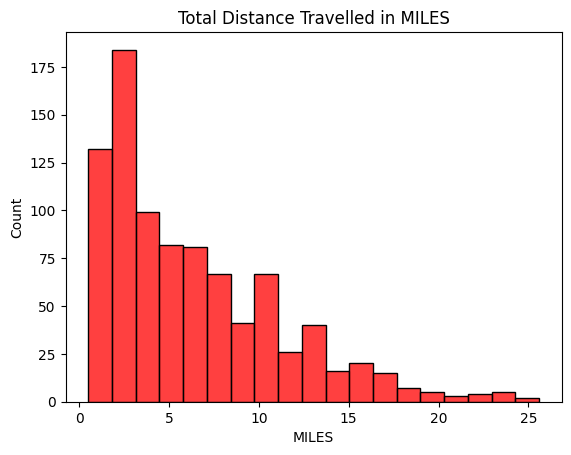

In [38]:
mat.title('Total Distance Travelled in MILES')
sea.histplot(df3.MILES,color='Red')
mat.show()

23. **Grafico de clasificacion de viajes por CATEGORIA**

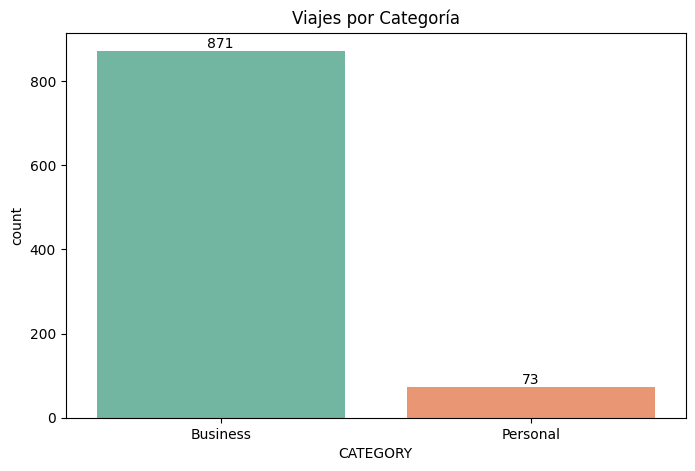

In [39]:
fig, ax = mat.subplots(figsize=(8,5))

grafica = sea.countplot(
    data=df,
    x='CATEGORY',
    hue='CATEGORY',
    palette='Set2',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Viajes por Categoría')

# Agregar etiquetas con totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

24. **Grafica de viajes por proposito(PURPOSE)**

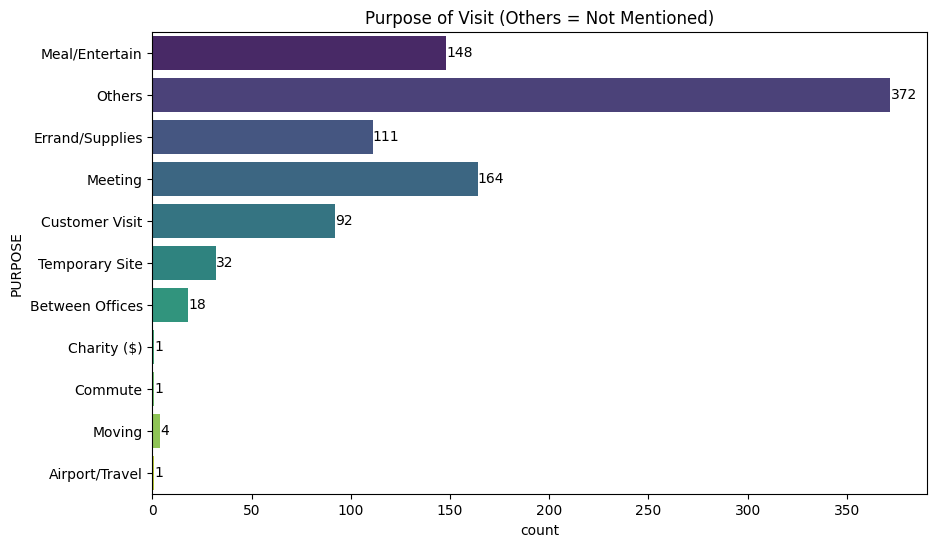

In [40]:
fig, ax = mat.subplots(figsize=(10,6))

grafica = sea.countplot(
    data=df,
    y='PURPOSE',
    hue='PURPOSE',
    dodge=False,
    palette='viridis',
    legend=False
)

# Título
ax.set_title('Purpose of Visit (Others = Not Mentioned)')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()


25. **Gráfico de Lugar de Abordaje(START)**

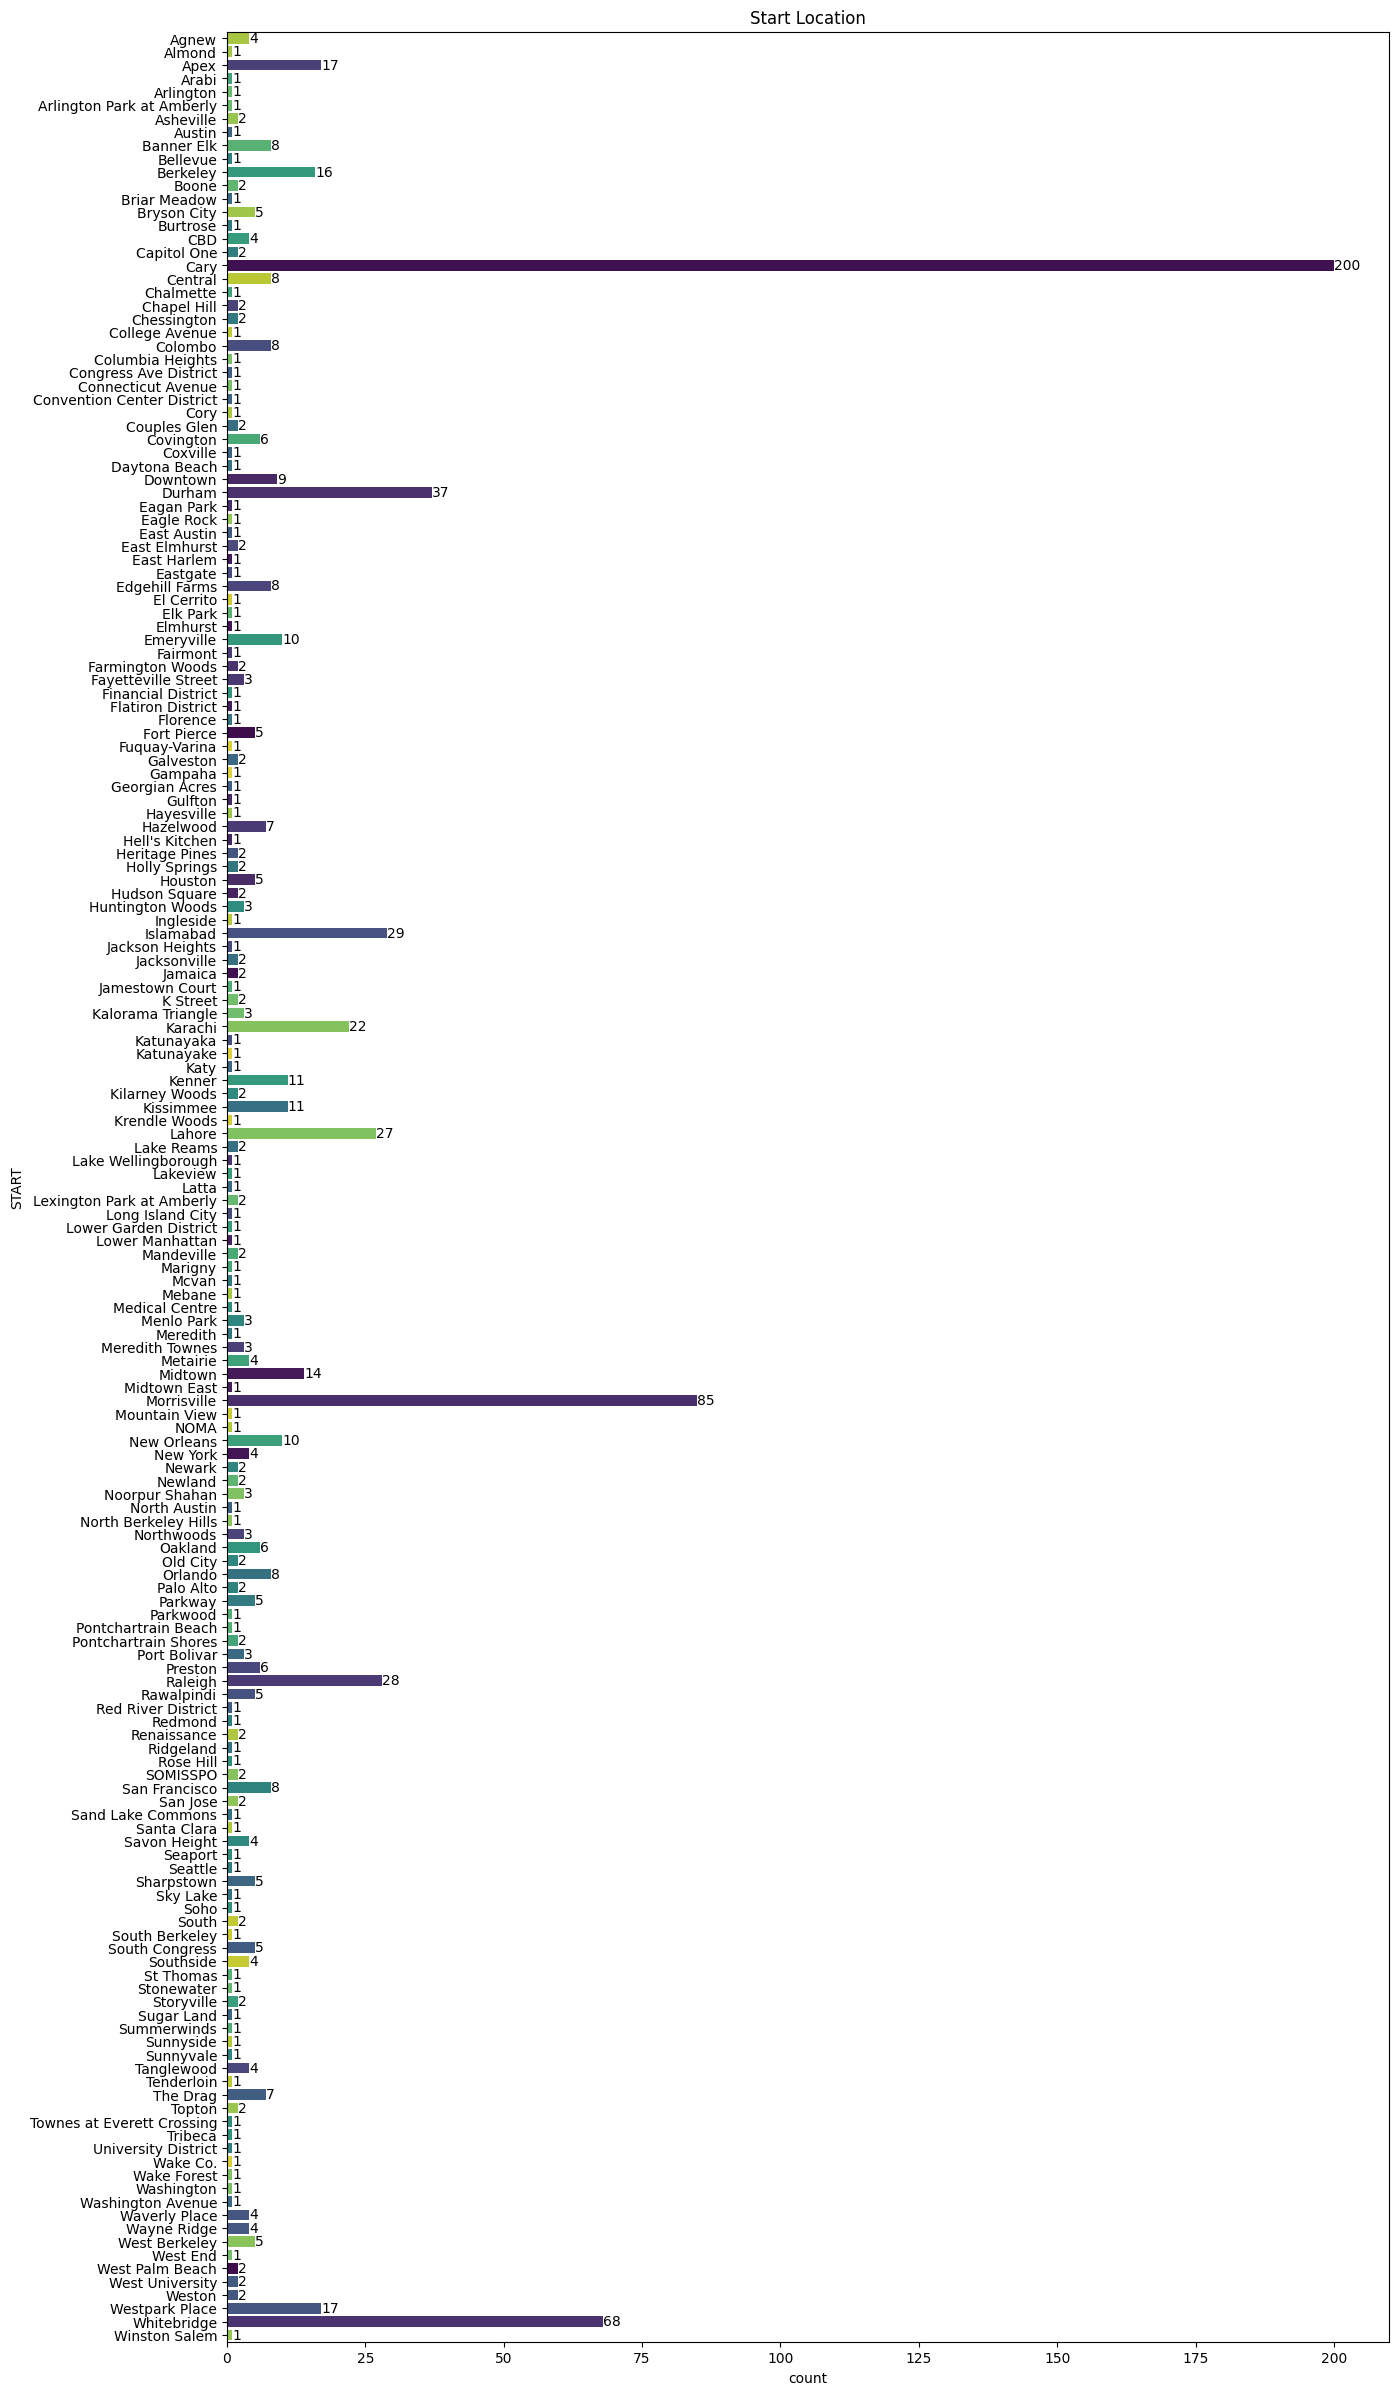

In [41]:
fig, ax = mat.subplots(figsize=(15,30))

# Ordenar alfabéticamente
orden = sorted(df['START'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='START',
    order=orden,
    hue='START',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Start Location')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()

26. **Grafica de lugar de llegada (STOP)**

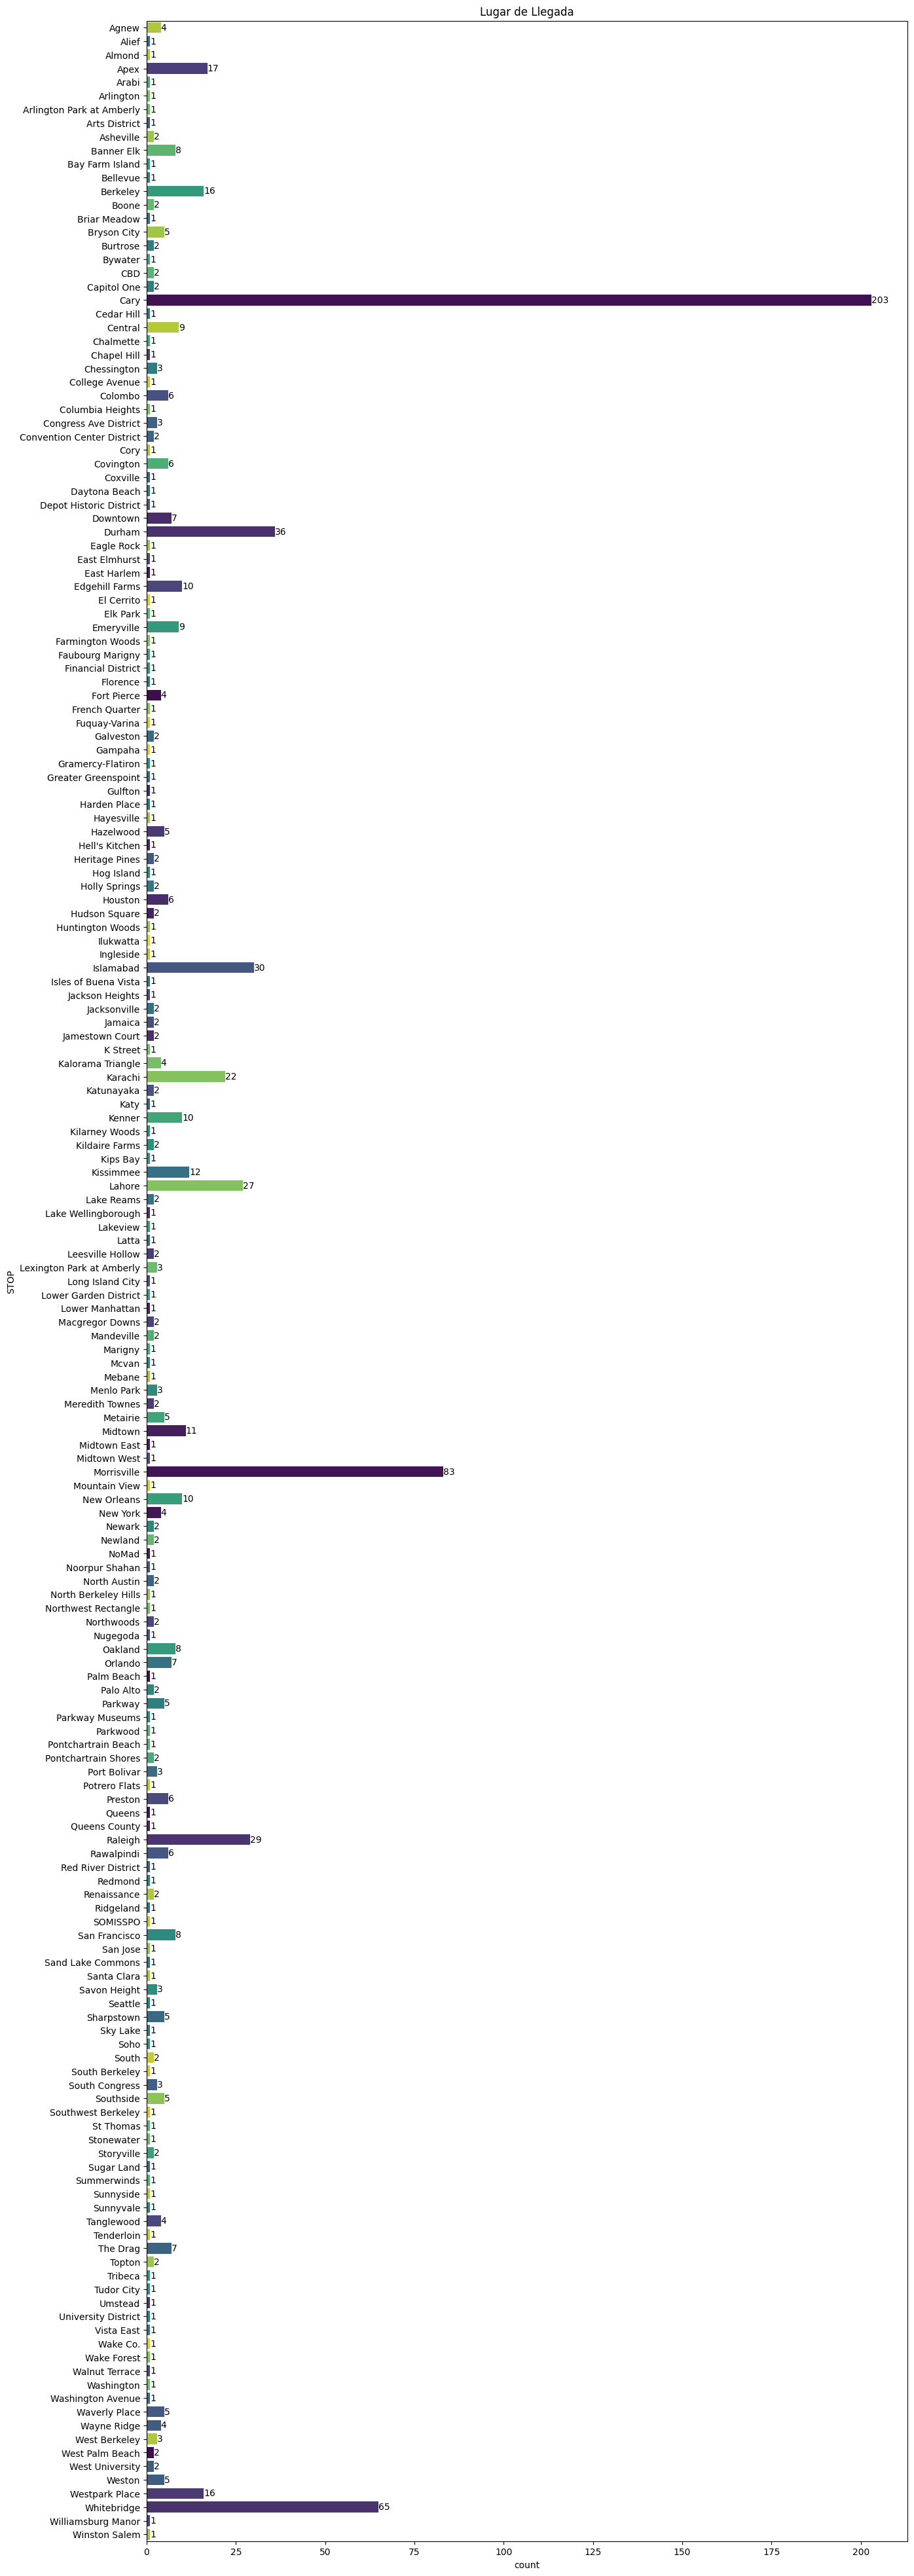

In [42]:
fig, ax = mat.subplots(figsize=(15,50))

# Ordenar alfabéticamente
orden = sorted(df['STOP'].dropna().unique())

grafica = sea.countplot(
    data=df,
    y='STOP',
    order=orden,
    hue='STOP',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax
)

# Título
ax.set_title('Lugar de Llegada')

# Agregar totales
for container in ax.containers:
    ax.bar_label(container)

mat.show()


**Conclusiones**

## Conclusiones del Análisis de Datos de Viajes de Uber

Este análisis exploratorio de datos de viajes de Uber ha revelado varias ideas clave y ha demostrado el proceso de limpieza y preparación de datos.

1.  **Limpieza y Preprocesamiento de Datos**:
    *   Se identificaron y eliminaron registros con ubicaciones de inicio ('START') y fin ('STOP') desconocidas, reduciendo el conjunto de datos de 1156 a 945 viajes.
    *   Se corrigieron caracteres ilegibles ('?') en las ubicaciones de inicio y fin, reemplazándolos con 'a' para estandarizar los nombres.
    *   Se rellenaron los valores faltantes en la columna 'PURPOSE' (propósito del viaje) con 'Others' para asegurar la integridad de los datos.
    *   Se segmentaron las fechas de inicio y fin para facilitar análisis temporales futuros.
    *   Se eliminó una fila final que parecía ser un total, lo que podría interferir con el análisis.

2.  **Análisis de Medidas de Tendencia Central y Dispersión**:
    *   La distancia recorrida ('MILES') mostró un rango amplio, desde un mínimo de 0.5 millas hasta un máximo de 12204.7 millas.
    *   La distancia promedio de los viajes fue de aproximadamente 22.8 millas, con una mediana de 5.3 millas, lo que sugiere una asimetría hacia viajes más cortos, a pesar de la presencia de algunos viajes extremadamente largos. La moda fue de 9.9 millas, indicando que esta es una distancia frecuente.
    *   Se aplicó un filtrado de valores atípicos utilizando percentiles (5% y 95%) y la puntuación Z-score (-1 a 1) para obtener un subconjunto de datos más representativo y menos influenciado por extremos, lo que permitió un análisis más robusto de las distancias típicas.

3.  **Visualización de Datos**:
    *   Los gráficos de barras revelaron que la mayoría de los viajes se clasifican como 'Business' (Negocios) en comparación con 'Personal'.
    *   El propósito de los viajes fue diverso, con 'Meeting' y 'Meal/Entertain' siendo propósitos comunes, además de una categoría significativa de 'Others' tras la imputación.
    *   Las visualizaciones de los lugares de inicio y destino ('START' y 'STOP') mostraron una distribución variada, destacando los puntos de partida y llegada más frecuentes.

En resumen, este análisis ha proporcionado una visión inicial del patrón de viajes de Uber, las distancias recorridas y los propósitos, al tiempo que ha ilustrado técnicas fundamentales de limpieza y preprocesamiento de datos para preparar el conjunto de datos para análisis más profundos. Los datos, una vez limpiados y ajustados para valores atípicos, presentan una distribución de distancias de viaje más concentrada y manejable para futuras investigaciones.